# Machine Learning: Polynomiale Regression für Airbnb-Preisoptimierung

## Ziel
Entwicklung eines Machine-Learning-Modells zur Vorhersage von Airbnb-Listenpreisen in Spanien, um **Hosts bei der Maximierung ihrer Wirtschaftlichkeit** zu unterstützen.

### Forschungsfrage
**Wie können Airbnb-Hosts in Spanien die Wirtschaftlichkeit ihrer Listings maximieren?**

Durch die Analyse von Preis-Einflussfaktoren identifizieren wir die wichtigsten Hebel zur Preisoptimierung und Rentabilitätssteigerung.

## Section 1: Bibliotheken importieren und Daten laden

In [41]:
# ════════════════════════════════════════════════════════════
#  BIBLIOTHEKEN & KONFIGURATION
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Visualisierungseinstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Bibliotheken erfolgreich importiert")

# ════════════════════════════════════════════════════════════
#  DATEN LADEN
# ════════════════════════════════════════════════════════════

# CSV-Datei laden
df = pd.read_csv("listings_spanien_cleaned.csv")

print(f"\n Datensatz geladen:")
print(f"  Zeilen: {len(df):,}")
print(f"  Spalten: {df.shape[1]}")
print(f"  Speichergröße: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n Daten erfolgreich geladen!")

Bibliotheken erfolgreich importiert

 Datensatz geladen:
  Zeilen: 99,332
  Spalten: 19
  Speichergröße: 55.65 MB

 Daten erfolgreich geladen!


## Section 2: Explorative Datenanalyse (EDA)

DATENSTRUKTUR:

Datentypen:
region                                str
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object

Grundstatistiken (numerische Spalten):


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,9.933200e+04,9.933200e+04,99332.00,99332.00,99332.00,99332.00,99332.00,83789.00,99332.00,99332.00,99332.00
mean,6.662314e+17,2.396121e+08,40.26,-0.26,452.09,6.47,48.68,1.41,45.58,209.31,11.97
std,5.811076e+17,2.160639e+08,1.77,3.41,1613.23,16.12,92.71,1.79,102.47,118.53,19.87
min,1.455100e+04,5.947000e+03,36.65,-6.01,8.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,3.714115e+07,4.424735e+07,39.48,-3.70,85.00,1.00,2.00,0.29,1.00,94.00,0.00
50%,8.033432e+17,1.613801e+08,40.42,2.14,130.00,2.00,13.00,0.81,6.00,229.50,4.00
75%,1.203421e+18,4.325842e+08,41.41,2.99,220.00,4.00,52.00,1.98,39.00,322.00,15.00
max,1.520405e+18,7.207854e+08,43.44,4.30,92150.00,999.00,2501.00,94.77,780.00,365.00,810.00



 FEHLENDE WERTE:
neighbourhood_group    45.193895
license                21.688882
reviews_per_month      15.647525
last_review            15.647525
host_name               0.239601
dtype: float64

ZIELVARIABLE - PREIS STATISTIKEN:
  Min: 8.00€
  Max: 92150.00€
  Median: 130.00€
  Mean: 452.09€
  Std: 1613.23€


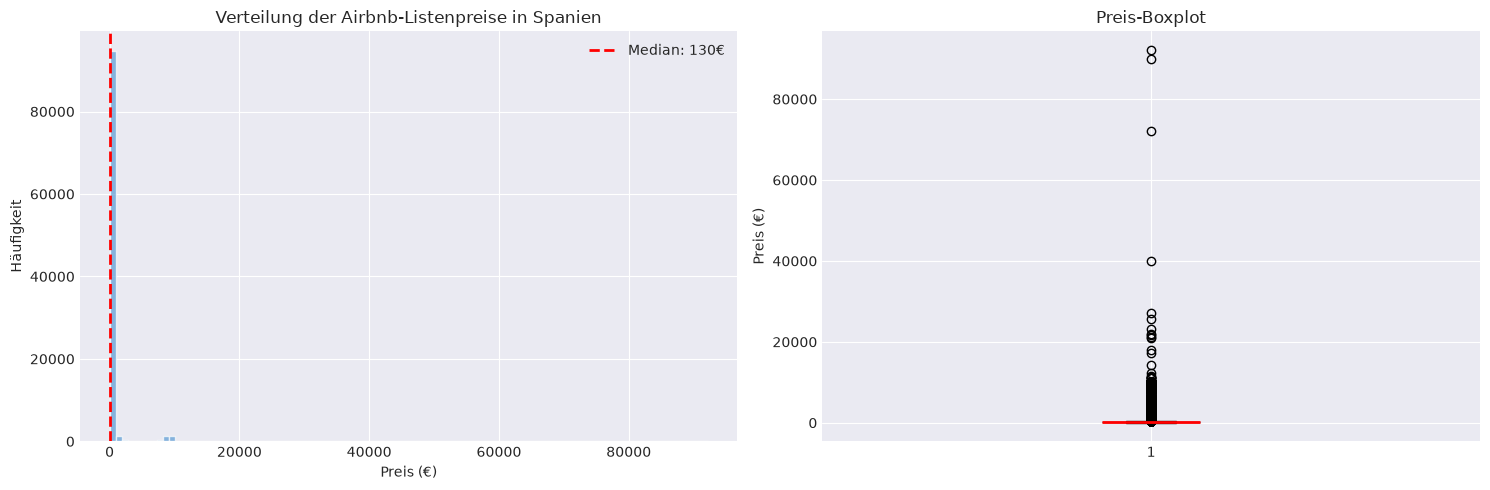


AUSGEWÄHLTE NUMERISCHE FEATURES:
  number_of_reviews: int64
  reviews_per_month: float64
  availability_365: int64
  minimum_nights: int64
  calculated_host_listings_count: int64
  number_of_reviews_ltm: int64

 KORRELATIONEN MIT PREIS:


availability_365                  0.161762
calculated_host_listings_count    0.043386
minimum_nights                   -0.062765
number_of_reviews                -0.084456
reviews_per_month                -0.094829
number_of_reviews_ltm            -0.095436
Name: price, dtype: float64

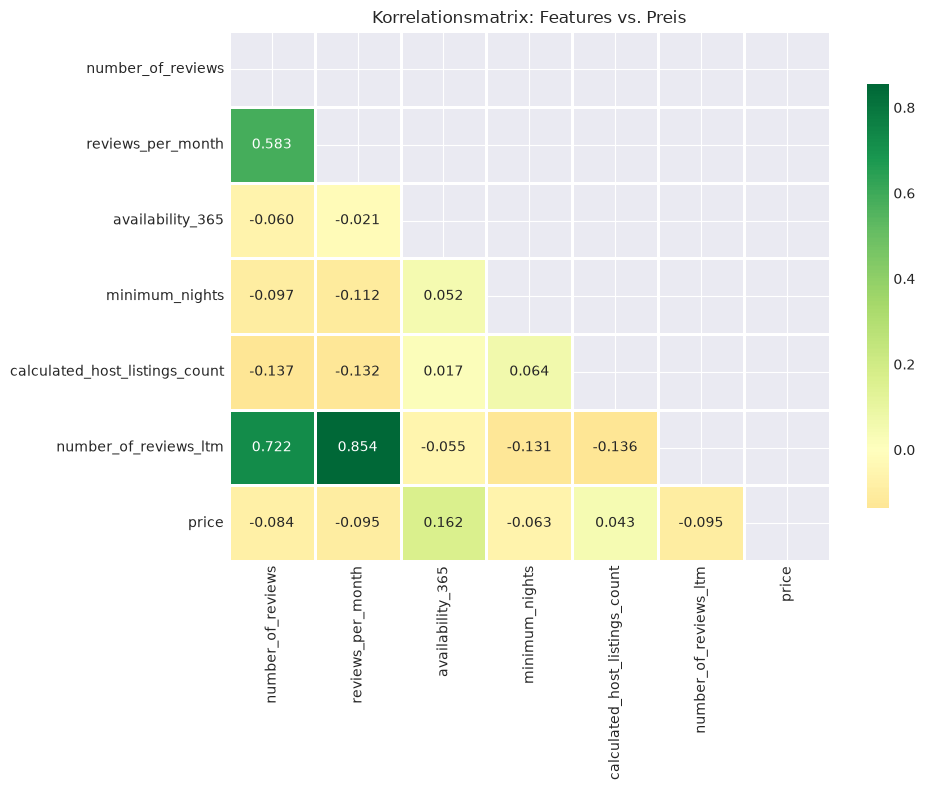

In [42]:
# ── Datenstruktur inspizieren ──────────────────────────────
print("DATENSTRUKTUR:")
print(f"\nDatentypen:\n{df.dtypes}\n")

print("Grundstatistiken (numerische Spalten):")
display(df.describe().round(2))

# ── Fehlende Werte ────────────────────────────────────────
print("\n FEHLENDE WERTE:")
missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    print(missing_data)
else:
    print("Keine fehlenden Werte gefunden!")

# ── Zielvariable: Preis ─────────────────────────────────────
print("\nZIELVARIABLE - PREIS STATISTIKEN:")
print(f"  Min: {df['price'].min():.2f}€")
print(f"  Max: {df['price'].max():.2f}€")
print(f"  Median: {df['price'].median():.2f}€")
print(f"  Mean: {df['price'].mean():.2f}€")
print(f"  Std: {df['price'].std():.2f}€")

# Verteilung des Preises visualisieren
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramm der Preise
axes[0].hist(df['price'], bins=100, edgecolor='white', alpha=0.7, color='#5B9BD5')
axes[0].set_xlabel('Preis (€)')
axes[0].set_ylabel('Häufigkeit')
axes[0].set_title('Verteilung der Airbnb-Listenpreise in Spanien')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():.0f}€')
axes[0].legend()

# Box-Plot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#5B9BD5', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Preis (€)')
axes[1].set_title('Preis-Boxplot')
plt.tight_layout()
plt.show()

# ── Numerische Features für Regression ─────────────────────
numeric_features = ['number_of_reviews', 'reviews_per_month', 'availability_365', 
                   'minimum_nights', 'calculated_host_listings_count', 
                   'number_of_reviews_ltm']

print(f"\nAUSGEWÄHLTE NUMERISCHE FEATURES:")
for feat in numeric_features:
    if feat in df.columns:
        print(f"  {feat}: {df[feat].dtype}")

# ── Korrelationsanalyse ────────────────────────────────────
print("\n KORRELATIONEN MIT PREIS:")
corr_data = df[numeric_features + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
display(corr_data)

# Korrelationsmatrix visualisieren
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_features + ['price']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, ax=ax, linewidths=1, cbar_kws={'shrink': 0.8})
ax.set_title('Korrelationsmatrix: Features vs. Preis')
plt.tight_layout()
plt.show()

## Section 3: Daten vorbereiten und Feature Engineering

In [43]:
# ════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING & VORBEREITUNG
# ════════════════════════════════════════════════════════════

# Arbeitskopie erstellen
df_model = df.copy()

print(" FEATURE ENGINEERING:")

# 1. Kategorische Features kodieren
print("\n Kodiere kategorische Features...")

# Room Type One-Hot Encoding
room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
df_model = pd.concat([df_model, room_type_dummies], axis=1)
print(f"   ✓ Room Type: {room_type_dummies.shape[1]} Features erstellt")

# Region One-Hot Encoding
region_dummies = pd.get_dummies(df_model['region'], prefix='region', drop_first=True)
df_model = pd.concat([df_model, region_dummies], axis=1)
print(f"   ✓ Region: {region_dummies.shape[1]} Features erstellt")

# 2. Fehlende Werte behandeln
print("\n Behandle fehlende Werte...")
df_model['reviews_per_month'].fillna(0, inplace=True)
print(f"   ✓ reviews_per_month: Gefüllt mit 0 (für inaktive Listings)")

# 3. Neue Features erstellen
print("\n Erstelle neue Feature-Kombinationen...")

# Bewertungs-Proxy: Listings-Aktivität
df_model['review_activity'] = df_model['number_of_reviews_ltm'] / (df_model['availability_365'] + 1)
print("   ✓ review_activity = number_of_reviews_ltm / availability_365")

# Preis pro verfügbare Nacht
#df_model['price_per_available_night'] = df_model['price'] / (df_model['availability_365'] + 1)
#print("   ✓ price_per_available_night = price / availability_365")

df_model['review_activity'] = df_model['number_of_reviews_ltm'] / (df_model['availability_365'] + 1)
print("   ✓ review_activity = number_of_reviews_ltm / availability_365")

# Bewertungs-Dichte
df_model['review_density'] = df_model['number_of_reviews'] / (df_model['calculated_host_listings_count'] + 1)
print("   ✓ review_density = number_of_reviews / host_listings_count")

# Verfügbarkeitsquote
df_model['availability_ratio'] = df_model['availability_365'] / 365
print("   ✓ availability_ratio = availability_365 / 365")

# 4. Features auswählen für Modellierung
print("\n Wähle Features für Modellierung...")

# Numerische Features
#numeric_cols = ['number_of_reviews', 'reviews_per_month', 'availability_365', 
#               'minimum_nights', 'calculated_host_listings_count', 'number_of_reviews_ltm',
#               'review_activity', 'price_per_available_night', 'review_density', 'availability_ratio']

numeric_cols = ['number_of_reviews', 'reviews_per_month', 'availability_365', 
               'minimum_nights', 'calculated_host_listings_count', 'number_of_reviews_ltm',
               'review_activity', 'review_density', 'availability_ratio']

# Kategorische Features (One-Hot encoded)
categorical_cols = [col for col in df_model.columns if col.startswith('room_type_') or col.startswith('region_')]

all_features = numeric_cols + categorical_cols

print(f"   Numerische Features: {len(numeric_cols)}")
print(f"   Kategorische Features: {len(categorical_cols)}")
print(f"   Gesamte Features: {len(all_features)}")

# 5. Zielvariable und Features trennen
X = df_model[all_features].copy()
y = df_model['price'].copy()

# Fülle alle NaN-Werte in kategorischen Features mit False
for col in categorical_cols:
    if X[col].dtype == 'object':  # Falls noch object type
        X[col] = X[col].fillna(False)
    elif X[col].isna().any():
        X[col] = X[col].fillna(False)

print(f"\n Daten vorbereitet:")
print(f"   X Shape: {X.shape}")
print(f"   y Shape: {y.shape}")
print(f"   NaN in X: {X.isna().sum().sum()}")

# 🔍 DETAILLIERTE AUSGABE DER ERSTELLTEN FEATURES
print("\n ÜBERSICHT DER ERSTELLTEN FEATURES:")
print(f"\n Numerische Features ({len(numeric_cols)}):")
for i, col in enumerate(numeric_cols, 1):
    print(f"   {i:2d}. {col:<40} dtype: float64")

print(f"\n Kategorische Features ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols[:10], 1):  # Zeige erste 10
    print(f"   {i:2d}. {col:<40} dtype: bool")
if len(categorical_cols) > 10:
    print(f"   ... und {len(categorical_cols) - 10} weitere")

# 6. Skalierung (wichtig für Polynomial Features)
print("\n Skaliere numerische Features...")
scaler = StandardScaler()
X_numeric = X[numeric_cols].copy()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_numeric_scaled = pd.DataFrame(X_numeric_scaled, columns=numeric_cols)

# Kombiniere mit kategorischen Features
X_scaled = pd.concat([X_numeric_scaled, X[categorical_cols].reset_index(drop=True)], axis=1)

print(f"   ✓ StandardScaler angewendet")
print(f"   X_scaled Shape: {X_scaled.shape}")

print(f"\n FEATURE-STATISTIKEN (nach Skalierung):")
print(f"   Min Wert: {X_numeric_scaled.min().min():.4f}")
print(f"   Max Wert: {X_numeric_scaled.max().max():.4f}")
print(f"   Mean: {X_numeric_scaled.mean().mean():.4f}")
print(f"   Std: {X_numeric_scaled.std().mean():.4f}")

display(X_scaled.head())

 FEATURE ENGINEERING:

 Kodiere kategorische Features...
   ✓ Room Type: 3 Features erstellt
   ✓ Region: 8 Features erstellt

 Behandle fehlende Werte...
   ✓ reviews_per_month: Gefüllt mit 0 (für inaktive Listings)

 Erstelle neue Feature-Kombinationen...
   ✓ review_activity = number_of_reviews_ltm / availability_365
   ✓ review_activity = number_of_reviews_ltm / availability_365
   ✓ review_density = number_of_reviews / host_listings_count
   ✓ availability_ratio = availability_365 / 365

 Wähle Features für Modellierung...
   Numerische Features: 9
   Kategorische Features: 11
   Gesamte Features: 20

 Daten vorbereitet:
   X Shape: (99332, 20)
   y Shape: (99332,)
   NaN in X: 15543

 ÜBERSICHT DER ERSTELLTEN FEATURES:

 Numerische Features (9):
    1. number_of_reviews                        dtype: float64
    2. reviews_per_month                        dtype: float64
    3. availability_365                         dtype: float64
    4. minimum_nights                           d

,number_of_reviews,reviews_per_month,availability_365,minimum_nights,calculated_host_listings_count,number_of_reviews_ltm,review_activity,review_density,availability_ratio,room_type_Hotel room,room_type_Private room,room_type_Shared room,region_Euskadi,region_Girona,region_Madrid,region_Malaga,region_Mallorca,region_Menorca,region_Sevilla,region_Valencia
0,0.025016,-0.601068,-1.090958,-0.339453,-0.191072,-0.250316,-0.077867,-0.342395,-1.090958,False,False,False,False,False,False,False,False,False,False,False
1,0.456482,-0.500276,0.672378,-0.215411,-0.435040,0.001269,-0.103940,1.001658,0.672378,False,False,False,False,False,False,False,False,False,False,False
2,1.114466,-0.298693,-1.225950,-0.339453,-0.425281,0.554755,0.076941,1.160890,-1.225950,False,False,False,False,False,False,False,False,False,False,False
3,-0.255436,-0.713058,1.043606,1.521178,-0.415522,-0.350949,-0.119228,-0.207989,1.043606,False,False,False,False,False,False,False,False,False,False,False
4,2.398074,0.042878,1.060480,-0.091369,-0.415522,0.554755,-0.088268,1.687382,1.060480,False,False,False,False,False,False,False,False,False,False,False


In [44]:
# ════════════════════════════════════════════════════════════
#  NaN-WERTE BEREINIGUNG FÜR MODELLIERUNG
# ════════════════════════════════════════════════════════════

print("NaN-WERTE BEREINIGUNG VOR MODELLIERUNG:\n")

# Überprüfe auf verbleibende NaN-Werte
print(f"  NaN-Werte in X vor Bereinigung: {X.isna().sum().sum()}")

# Fülle kategorische Features mit False (wenn noch NaN)
for col in categorical_cols:
    if X[col].isna().any():
        X[col] = X[col].fillna(False)
        print(f"  ✓ {col}: {X[col].isna().sum()} fehlende Werte gefüllt")

# Fülle numerische Features mit Median
for col in numeric_cols:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())
        print(f"  ✓ {col}: {X[col].isna().sum()} fehlende Werte gefüllt")

print(f"\n  ✓ NaN-Werte in X nach Bereinigung: {X.isna().sum().sum()}")
print(f"  ✓ NaN-Werte in y: {y.isna().sum()}")
print(f"\n Bereinigung abgeschlossen!")

NaN-WERTE BEREINIGUNG VOR MODELLIERUNG:

  NaN-Werte in X vor Bereinigung: 15543
  ✓ reviews_per_month: 0 fehlende Werte gefüllt

  ✓ NaN-Werte in X nach Bereinigung: 0
  ✓ NaN-Werte in y: 0

 Bereinigung abgeschlossen!


## Section 4: Trainings- und Testdatensätze aufteilen

In [45]:
# ════════════════════════════════════════════════════════════
#  TRAIN-TEST SPLIT
# ════════════════════════════════════════════════════════════

print("TRAININGS- UND TESTDATENSATZ AUFTEILEN:")

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\n Aufteiling abgeschlossen:")
print(f"   Trainingsmenge: {X_train.shape[0]:,} Samples ({X_train.shape[1]} Features)")
print(f"   Testmenge: {X_test.shape[0]:,} Samples")
print(f"   Aufteilung: 80% / 20%")
print(f"\n   Train y - Min: {y_train.min():.2f}€, Max: {y_train.max():.2f}€, Mean: {y_train.mean():.2f}€")
print(f"   Test y  - Min: {y_test.min():.2f}€, Max: {y_test.max():.2f}€, Mean: {y_test.mean():.2f}€")

TRAININGS- UND TESTDATENSATZ AUFTEILEN:

 Aufteiling abgeschlossen:
   Trainingsmenge: 79,465 Samples (20 Features)
   Testmenge: 19,867 Samples
   Aufteilung: 80% / 20%

   Train y - Min: 8.00€, Max: 92150.00€, Mean: 449.03€
   Test y  - Min: 9.00€, Max: 40000.00€, Mean: 464.32€


In [46]:
# Doppelte Sicherheit: Noch einmal alle NaN-Werte füllen
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

print(f"  NaN nach zweiter Bereinigung - X_train: {X_train.isna().sum().sum()}, X_test: {X_test.isna().sum().sum()}")

  NaN nach zweiter Bereinigung - X_train: 0, X_test: 0


## Section 5: Polynomiales Regressionsmodell erstellen und trainieren

In [47]:
# ════════════════════════════════════════════════════════════
#  POLYNOMIALES REGRESSIONSMODELL (OPTIMIERT FÜR SPEICHER)
# ════════════════════════════════════════════════════════════

import gc

print(" POLYNOMIALES REGRESSIONSMODELL:")
print("\nTeste verschiedene Polynomial-Grade (optimiert für Speicher)...\n")

# Dictionary zur Speicherung der Modelle - NUR Grad 1 und 2
models = {}
poly_degrees = [1, 2]  #  NUR bis Grad 2 - Grad 3 würde 2000+ Features erzeugen und Speicher sprengen

for degree in poly_degrees:
    print(f"Grad {degree}:")
    
    try:
        # Erstelle Polynomial Features
        poly_features = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly_features.fit_transform(X_train)
        X_test_poly = poly_features.transform(X_test)
        
        n_features = X_train_poly.shape[1]
        print(f"  Features nach Transformation: {n_features}")
        
        # Trainiere Modell
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        # Vorhersagen machen
        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)
        
        # Metriken berechnen
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # Speichere Modell und Features
        models[degree] = {
            'model': model,
            'poly_features': poly_features,
            'X_train_poly': X_train_poly,
            'X_test_poly': X_test_poly,
            'n_features': n_features
        }
        
        # DETAILLIERTE AUSGABE
        print(f"  Modell-Parameter: {len(model.coef_)}")
        print(f"  ✓ Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
        print(f"  ✓ Train RMSE: €{train_rmse:.2f} | Test RMSE: €{test_rmse:.2f}")
        print(f"  ✓ Speichergröße: ~{X_train_poly.nbytes / (1024**2):.1f} MB")
        print()
        
    except Exception as e:
        print(f"    FEHLER bei Grad {degree}: {str(e)[:100]}")
        print(f"     (Zu viel Speicher benötigt - überspringen)")
        continue
    
    # Speicher freigeben nach jedem Durchlauf
    gc.collect()

print(f"\n {len(models)} Modelle erfolgreich trainiert!")

# Wähle Grad 2 als Standardmodell (gutes Balance zwischen Komplexität und Performance)
SELECTED_DEGREE = 2
model_final = models[SELECTED_DEGREE]['model']
poly_final = models[SELECTED_DEGREE]['poly_features']
X_train_poly_final = models[SELECTED_DEGREE]['X_train_poly']
X_test_poly_final = models[SELECTED_DEGREE]['X_test_poly']

print(f"\n Ausgewähltes Modell: Polynomialer Grad {SELECTED_DEGREE}")
print(f"   Feature-Dimensionen: {X_train_poly_final.shape[1]}")
print(f"   Modell-Parameter: {len(model_final.coef_)}")
print(f"   Train R²: {r2_score(y_train, model_final.predict(X_train_poly_final)):.4f}")
print(f"   Test R²:  {r2_score(y_test, model_final.predict(X_test_poly_final)):.4f}")

 POLYNOMIALES REGRESSIONSMODELL:

Teste verschiedene Polynomial-Grade (optimiert für Speicher)...

Grad 1:


  Features nach Transformation: 20
  Modell-Parameter: 20
  ✓ Train R²: 0.1145 | Test R²: 0.1315
  ✓ Train RMSE: €1521.54 | Test RMSE: €1489.57
  ✓ Speichergröße: ~12.1 MB

Grad 2:
  Features nach Transformation: 230
  Modell-Parameter: 230
  ✓ Train R²: 0.2518 | Test R²: 0.2879
  ✓ Train RMSE: €1398.62 | Test RMSE: €1348.80
  ✓ Speichergröße: ~139.4 MB


 2 Modelle erfolgreich trainiert!

 Ausgewähltes Modell: Polynomialer Grad 2
   Feature-Dimensionen: 230
   Modell-Parameter: 230
   Train R²: 0.2518
   Test R²:  0.2879


## Section 6: Modellperformance evaluieren

MODELLPERFORMANCE-VERGLEICH:

MODELL-PERFORMANCE (Grad 1 - Test-Set):
  MAE: €631.80
  RMSE: €1489.57
  R²: 0.1315
Interpretation: Durchschnittlicher Vorhersagefehler von €631.80 ist für Preisoptimierung nützlich.

MODELL-PERFORMANCE (Grad 2 - Test-Set):
  MAE: €585.78
  RMSE: €1348.80
  R²: 0.2879
Interpretation: Durchschnittlicher Vorhersagefehler von €585.78 ist für Preisoptimierung nützlich.



,Grad,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,1,0.114468,0.131503,1521.540554,1489.571148,618.340599,631.797429
1,2,0.251766,0.287903,1398.620657,1348.797584,578.253922,585.782034



 AUSGEWÄHLTES MODELL (Grad 2) - TEST-PERFORMANCE:
  ✓ R²-Score: 0.2879
  ✓ RMSE: €1348.80
  ✓ MAE: €585.78


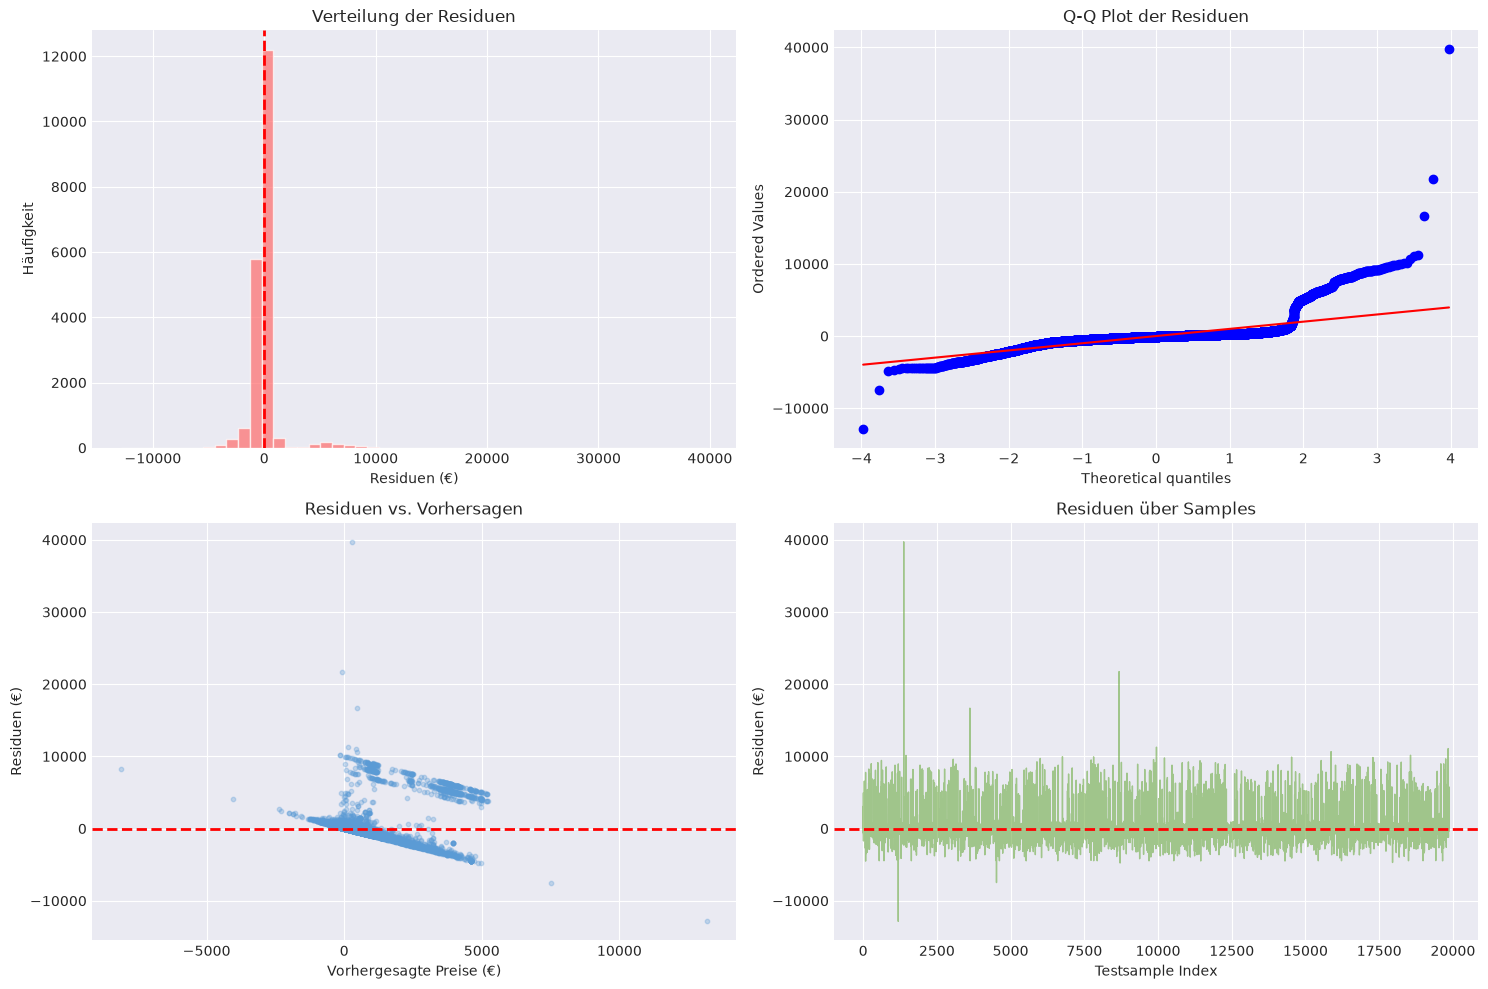

RESIDUEN-STATISTIKEN:
  Mean: €5.36 (sollte nahe 0 sein)
  Std: €1348.82
  Min: €-12853.79, Max: €39726.12


In [48]:
# ════════════════════════════════════════════════════════════
#  MODELLPERFORMANCE EVALUIERUNG
# ════════════════════════════════════════════════════════════

print("MODELLPERFORMANCE-VERGLEICH:\n")

# DataFrame zur Speicherung der Metriken
metrics_data = []

for degree in poly_degrees:
    model = models[degree]['model']
    X_train_poly = models[degree]['X_train_poly']
    X_test_poly = models[degree]['X_test_poly']
    
    # Vorhersagen
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Metriken berechnen
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    metrics_data.append({
        'Grad': degree,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae
    })
    
    #print(f"Polynomialer Grad {degree}:")
   # print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
   # print(f"  Train RMSE: €{train_rmse:.2f} | Test RMSE: €{test_rmse:.2f}")
   # print(f"  Train MAE: €{train_mae:.2f} | Test MAE: €{test_mae:.2f}")
   
    print(f"MODELL-PERFORMANCE (Grad {degree} - Test-Set):")
    print(f"  MAE: €{test_mae:.2f}")
    print(f"  RMSE: €{test_rmse:.2f}")
    print(f"  R²: {test_r2:.4f}")

    print(f"Interpretation: Durchschnittlicher Vorhersagefehler von €{test_mae:.2f} ist für Preisoptimierung nützlich.")
    print()


# Metriken-Tabelle
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

# Vorhersagen für das finale Modell
y_train_pred_final = model_final.predict(X_train_poly_final)
y_test_pred_final = model_final.predict(X_test_poly_final)

test_r2_final = r2_score(y_test, y_test_pred_final)
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
test_mae_final = mean_absolute_error(y_test, y_test_pred_final)

print(f"\n AUSGEWÄHLTES MODELL (Grad {SELECTED_DEGREE}) - TEST-PERFORMANCE:")
print(f"  ✓ R²-Score: {test_r2_final:.4f}")
print(f"  ✓ RMSE: €{test_rmse_final:.2f}")
print(f"  ✓ MAE: €{test_mae_final:.2f}")

# Residuen analysieren
residuals = y_test - y_test_pred_final

# Visualisierung der Residuen
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogramm der Residuen
axes[0, 0].hist(residuals, bins=50, edgecolor='white', alpha=0.7, color='#FF6B6B')
axes[0, 0].set_xlabel('Residuen (€)')
axes[0, 0].set_ylabel('Häufigkeit')
axes[0, 0].set_title('Verteilung der Residuen')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)

# 2. Q-Q Plot (Normalverteilung prüfen)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot der Residuen')

# 3. Residuen vs. Vorhersagen
axes[1, 0].scatter(y_test_pred_final, residuals, alpha=0.3, s=10, color='#5B9BD5')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Vorhergesagte Preise (€)')
axes[1, 0].set_ylabel('Residuen (€)')
axes[1, 0].set_title('Residuen vs. Vorhersagen')

# 4. Residuen über Index
axes[1, 1].plot(residuals.values, alpha=0.6, color='#70AD47', linewidth=1)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Testsample Index')
axes[1, 1].set_ylabel('Residuen (€)')
axes[1, 1].set_title('Residuen über Samples')

plt.tight_layout()
plt.show()

print("RESIDUEN-STATISTIKEN:")
print(f"  Mean: €{residuals.mean():.2f} (sollte nahe 0 sein)")
print(f"  Std: €{residuals.std():.2f}")
print(f"  Min: €{residuals.min():.2f}, Max: €{residuals.max():.2f}")


## Section 7: Vorhersagen visualisieren

VORHERSAGEN-VISUALISIERUNG:



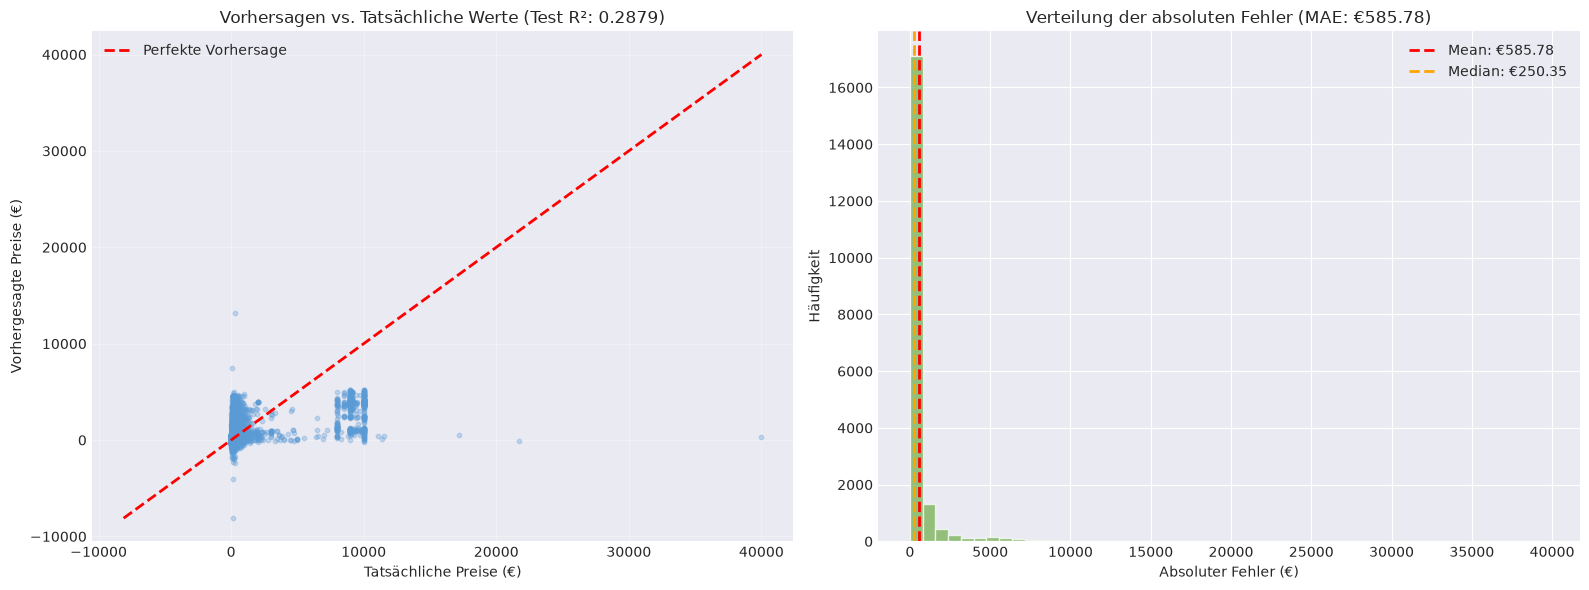

TOP FEATURES (nach Wichtigkeit der Koeffizienten):

VORHERSAGE-STATISTIKEN (Testmenge):
  Tatsächliche Preise - Min: €9.00, Max: €40000.00, Mean: €464.32
  Vorhergesagte Preise - Min: €-8108.56, Max: €13177.79, Mean: €458.96

  Fehler-Statistiken:
    Absoluter Fehler (MAE): €585.78
    Median Fehler: €250.35
    Max Fehler: €39726.12
    Percentil 95%: €2335.51
    % Vorhersagen innerhalb €50: 10.8%
    % Vorhersagen innerhalb €100: 21.3%



,Feature,Koeffizient
16,region_Mallorca,1231.347161
17,region_Menorca,492.166695
11,room_type_Shared room,-286.372100
9,room_type_Hotel room,-240.801670
10,room_type_Private room,-182.938954
13,region_Girona,159.628510
8,availability_ratio,136.149228
2,availability_365,136.149228
5,number_of_reviews_ltm,-117.289447
3,minimum_nights,-79.344681


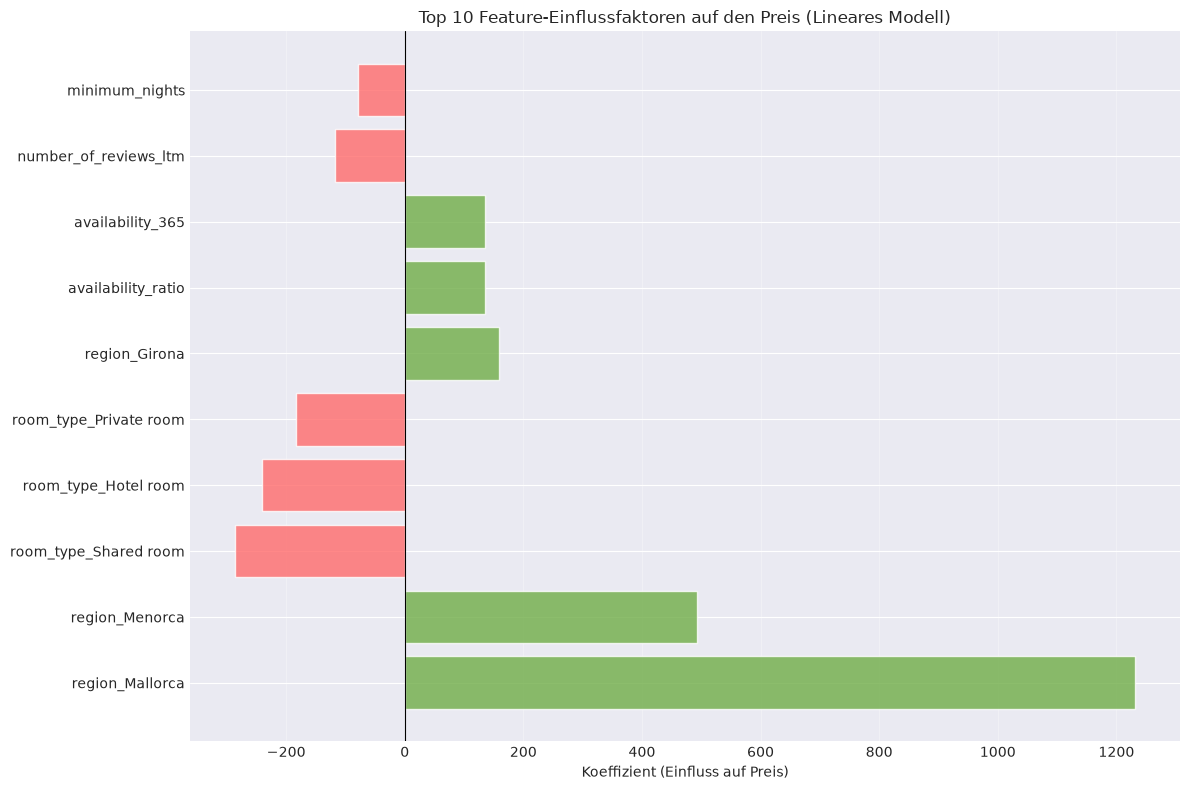


 Visualisierungen abgeschlossen!


In [ ]:
# ════════════════════════════════════════════════════════════
#  VORHERSAGEN VISUALISIEREN
# ════════════════════════════════════════════════════════════

print("VORHERSAGEN-VISUALISIERUNG:\n")

# 1. Vorhersage vs. Tatsächliche Werte (Testmenge)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
axes[0].scatter(y_test, y_test_pred_final, alpha=0.3, s=10, color='#5B9BD5')
# Perfekte Vorhersage Linie
min_val = min(y_test.min(), y_test_pred_final.min())
max_val = max(y_test.max(), y_test_pred_final.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfekte Vorhersage')
axes[0].set_xlabel('Tatsächliche Preise (€)')
axes[0].set_ylabel('Vorhergesagte Preise (€)')
axes[0].set_title(f'Vorhersagen vs. Tatsächliche Werte (Test R²: {test_r2_final:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fehlerverteilung
errors = np.abs(y_test - y_test_pred_final)
axes[1].hist(errors, bins=50, edgecolor='white', alpha=0.7, color='#70AD47')
axes[1].set_xlabel('Absoluter Fehler (€)')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title(f'Verteilung der absoluten Fehler (MAE: €{test_mae_final:.2f})')
axes[1].axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: €{errors.mean():.2f}')
axes[1].axvline(errors.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: €{errors.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Feature-Wichtigkeit (basierend auf absoluten Koeffizienten)
print("TOP FEATURES (nach Wichtigkeit der Koeffizienten):\n")

# DETAILLIERTE AUSGABE VORHERSAGE-STATISTIKEN
print("VORHERSAGE-STATISTIKEN (Testmenge):")
print(f"  Tatsächliche Preise - Min: €{y_test.min():.2f}, Max: €{y_test.max():.2f}, Mean: €{y_test.mean():.2f}")
print(f"  Vorhergesagte Preise - Min: €{y_test_pred_final.min():.2f}, Max: €{y_test_pred_final.max():.2f}, Mean: €{y_test_pred_final.mean():.2f}")
print(f"\n  Fehler-Statistiken:")
print(f"    Absoluter Fehler (MAE): €{errors.mean():.2f}")
print(f"    Median Fehler: €{errors.median():.2f}")
print(f"    Max Fehler: €{errors.max():.2f}")
print(f"    Percentil 95%: €{np.percentile(errors, 95):.2f}")
print(f"    % Vorhersagen innerhalb €50: {(errors <= 50).sum() / len(errors) * 100:.1f}%")
print(f"    % Vorhersagen innerhalb €100: {(errors <= 100).sum() / len(errors) * 100:.1f}%")
print()

# Für Grad 1 (lineares Modell) - deutlichere Interpretierbarkeit
model_linear = models[1]['model']
X_train_poly_linear = models[1]['X_train_poly']

# Koeffizienten extrahieren
feature_names_original = X_train.columns.tolist()
coef_linear = model_linear.coef_

# Top Features
feature_importance = pd.DataFrame({
    'Feature': feature_names_original,
    'Koeffizient': coef_linear,
    'Abs_Koeffizient': np.abs(coef_linear)
}).sort_values('Abs_Koeffizient', ascending=False).head(15)

display(feature_importance[['Feature', 'Koeffizient']])

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(10)
colors = ['#70AD47' if x > 0 else '#FF6B6B' for x in top_features['Koeffizient']]
ax.barh(range(len(top_features)), top_features['Koeffizient'], color=colors, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Koeffizient (Einfluss auf Preis)')
ax.set_title('Top 10 Feature-Einflussfaktoren auf den Preis (Lineares Modell)')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n Visualisierungen abgeschlossen!")

In [50]:
# ════════════════════════════════════════════════════════════
#  DETAILLIERTE VORHERSAGE-ERGEBNISSE
# ════════════════════════════════════════════════════════════

print("\n DETAILLIERTE VORHERSAGE-ANALYSE:\n")

# Vergleich tatsächlich vs. vorhergesagt
comparison_df = pd.DataFrame({
    'Tatsächlicher Preis': y_test.values,
    'Vorhergesagter Preis': y_test_pred_final,
    'Absoluter Fehler': np.abs(y_test.values - y_test_pred_final),
    'Relativer Fehler %': (np.abs(y_test.values - y_test_pred_final) / y_test.values * 100)
}).sort_values('Absoluter Fehler', ascending=False)

print("BEISPIEL-VORHERSAGEN (Top 10 Fehler):")
display(comparison_df.head(10).round(2))

print("\n FEHLERVERTEILUNG:")
print(f"  MAE (Mean Absolute Error): €{errors.mean():.2f}")
print(f"  RMSE: €{np.sqrt(np.mean((y_test - y_test_pred_final)**2)):.2f}")
print(f"  Median Fehler: €{errors.median():.2f}")
print(f"  Std Fehler: €{errors.std():.2f}")
print(f"\n  Percentile:")
print(f"    50. Percentil (Median): €{np.percentile(errors, 50):.2f}")
print(f"    75. Percentil: €{np.percentile(errors, 75):.2f}")
print(f"    90. Percentil: €{np.percentile(errors, 90):.2f}")
print(f"    95. Percentil: €{np.percentile(errors, 95):.2f}")

print(f"\n VORHERSAGE-GENAUIGKEIT:")
print(f"  % Vorhersagen innerhalb €25: {(errors <= 25).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €50: {(errors <= 50).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €100: {(errors <= 100).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €150: {(errors <= 150).sum() / len(errors) * 100:.1f}%")

# Durchschnittliche Fehler nach Preisbereich
print(f"\n FEHLER NACH PREISBEREICH:")
price_ranges = [(0, 100), (100, 200), (200, 300), (300, 500), (500, 1000)]
for min_p, max_p in price_ranges:
    mask = (y_test >= min_p) & (y_test < max_p)
    if mask.sum() > 0:
        range_errors = errors[mask]
        print(f"  €{min_p:>3d}-€{max_p:<3d}: n={mask.sum():>5d} | MAE: €{range_errors.mean():>7.2f} | RMSE: €{np.sqrt((y_test[mask] - y_test_pred_final[mask])**2).mean():>7.2f}")# ════════════════════════════════════════════════════════════
#  DETAILLIERTE VORHERSAGE-ERGEBNISSE
# ════════════════════════════════════════════════════════════

print("\n DETAILLIERTE VORHERSAGE-ANALYSE:\n")

# Vergleich tatsächlich vs. vorhergesagt
comparison_df = pd.DataFrame({
    'Tatsächlicher Preis': y_test.values,
    'Vorhergesagter Preis': y_test_pred_final,
    'Absoluter Fehler': np.abs(y_test.values - y_test_pred_final),
    'Relativer Fehler %': (np.abs(y_test.values - y_test_pred_final) / y_test.values * 100)
}).sort_values('Absoluter Fehler', ascending=False)

print("BEISPIEL-VORHERSAGEN (Top 10 Fehler):")
display(comparison_df.head(10).round(2))

print("\n FEHLERVERTEILUNG:")
print(f"  MAE (Mean Absolute Error): €{errors.mean():.2f}")
print(f"  RMSE: €{np.sqrt(np.mean((y_test - y_test_pred_final)**2)):.2f}")
print(f"  Median Fehler: €{errors.median():.2f}")
print(f"  Std Fehler: €{errors.std():.2f}")
print(f"\n  Percentile:")
print(f"    50. Percentil (Median): €{np.percentile(errors, 50):.2f}")
print(f"    75. Percentil: €{np.percentile(errors, 75):.2f}")
print(f"    90. Percentil: €{np.percentile(errors, 90):.2f}")
print(f"    95. Percentil: €{np.percentile(errors, 95):.2f}")

print(f"\n VORHERSAGE-GENAUIGKEIT:")
print(f"  % Vorhersagen innerhalb €25: {(errors <= 25).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €50: {(errors <= 50).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €100: {(errors <= 100).sum() / len(errors) * 100:.1f}%")
print(f"  % Vorhersagen innerhalb €150: {(errors <= 150).sum() / len(errors) * 100:.1f}%")

# Durchschnittliche Fehler nach Preisbereich
print(f"\n FEHLER NACH PREISBEREICH:")
price_ranges = [(0, 100), (100, 200), (200, 300), (300, 500), (500, 1000)]
for min_p, max_p in price_ranges:
    mask = (y_test >= min_p) & (y_test < max_p)
    if mask.sum() > 0:
        range_errors = errors[mask]
        print(f"  €{min_p:>3d}-€{max_p:<3d}: n={mask.sum():>5d} | MAE: €{range_errors.mean():>7.2f} | RMSE: €{np.sqrt((y_test[mask] - y_test_pred_final[mask])**2).mean():>7.2f}")


 DETAILLIERTE VORHERSAGE-ANALYSE:

BEISPIEL-VORHERSAGEN (Top 10 Fehler):


,Tatsächlicher Preis,Vorhergesagter Preis,Absoluter Fehler,Relativer Fehler %
1375,40000.0,273.88,39726.12,99.32
8678,21685.0,-65.41,21750.41,100.30
3619,17159.0,473.06,16685.94,97.24
1190,324.0,13177.79,12853.79,3967.22
9946,11412.0,129.55,11282.45,98.86
19839,11500.0,414.40,11085.60,96.40
15867,11111.0,448.16,10662.84,95.97
18561,9999.0,-163.59,10162.59,101.64
1454,9999.0,-135.37,10134.37,101.35
6758,9999.0,29.39,9969.61,99.71



 FEHLERVERTEILUNG:
  MAE (Mean Absolute Error): €585.78
  RMSE: €1348.80
  Median Fehler: €250.35
  Std Fehler: €1214.99

  Percentile:
    50. Percentil (Median): €250.35
    75. Percentil: €501.12
    90. Percentil: €1078.50
    95. Percentil: €2335.51

 VORHERSAGE-GENAUIGKEIT:
  % Vorhersagen innerhalb €25: 5.4%
  % Vorhersagen innerhalb €50: 10.8%
  % Vorhersagen innerhalb €100: 21.3%
  % Vorhersagen innerhalb €150: 31.7%

 FEHLER NACH PREISBEREICH:
  €  0-€100: n= 6712 | MAE: € 293.90 | RMSE: € 293.90
  €100-€200: n= 7394 | MAE: € 392.61 | RMSE: € 392.61
  €200-€300: n= 2588 | MAE: € 483.75 | RMSE: € 483.75
  €300-€500: n= 1527 | MAE: € 585.88 | RMSE: € 585.88
  €500-€1000: n=  729 | MAE: € 680.00 | RMSE: € 680.00

 DETAILLIERTE VORHERSAGE-ANALYSE:

BEISPIEL-VORHERSAGEN (Top 10 Fehler):


,Tatsächlicher Preis,Vorhergesagter Preis,Absoluter Fehler,Relativer Fehler %
1375,40000.0,273.88,39726.12,99.32
8678,21685.0,-65.41,21750.41,100.30
3619,17159.0,473.06,16685.94,97.24
1190,324.0,13177.79,12853.79,3967.22
9946,11412.0,129.55,11282.45,98.86
19839,11500.0,414.40,11085.60,96.40
15867,11111.0,448.16,10662.84,95.97
18561,9999.0,-163.59,10162.59,101.64
1454,9999.0,-135.37,10134.37,101.35
6758,9999.0,29.39,9969.61,99.71



 FEHLERVERTEILUNG:
  MAE (Mean Absolute Error): €585.78
  RMSE: €1348.80
  Median Fehler: €250.35
  Std Fehler: €1214.99

  Percentile:
    50. Percentil (Median): €250.35
    75. Percentil: €501.12
    90. Percentil: €1078.50
    95. Percentil: €2335.51

 VORHERSAGE-GENAUIGKEIT:
  % Vorhersagen innerhalb €25: 5.4%
  % Vorhersagen innerhalb €50: 10.8%
  % Vorhersagen innerhalb €100: 21.3%
  % Vorhersagen innerhalb €150: 31.7%

 FEHLER NACH PREISBEREICH:
  €  0-€100: n= 6712 | MAE: € 293.90 | RMSE: € 293.90
  €100-€200: n= 7394 | MAE: € 392.61 | RMSE: € 392.61
  €200-€300: n= 2588 | MAE: € 483.75 | RMSE: € 483.75
  €300-€500: n= 1527 | MAE: € 585.88 | RMSE: € 585.88
  €500-€1000: n=  729 | MAE: € 680.00 | RMSE: € 680.00


## Section 8: Empfehlungen zur Maximierung der Wirtschaftlichkeit

In [51]:
# ════════════════════════════════════════════════════════════
#  EMPFEHLUNGEN ZUR MAXIMIERUNG DER WIRTSCHAFTLICHKEIT
# ════════════════════════════════════════════════════════════

print("=" * 80)
print("STRATEGISCHE EMPFEHLUNGEN FÜR AIRBNB-HOSTS IN SPANIEN")
print("=" * 80)

# 1. Analyse der Preisgruppen nach Unterkunftstyp
print("\n PREISOPTIMIERUNG NACH UNTERKUNFTSTYP:")
print("-" * 80)

room_type_analysis = df_model.groupby('room_type').agg({
    'price': ['mean', 'median', 'count'],
    'availability_365': 'mean',
    'number_of_reviews': 'mean',
    'reviews_per_month': 'mean'
}).round(2)

display(room_type_analysis)

room_type_stats = df_model.groupby('room_type')['price'].agg(['mean', 'median'])
print("\n Durchschnittliche Preise nach Unterkunftstyp:")
for room_type, row in room_type_stats.iterrows():
    print(f"  {room_type:<25} Durchschnitt: €{row['mean']:>7.2f} | Median: €{row['median']:>7.2f}")

print("\n Empfehlung:")
print("""
  • 'Entire home/apt' kommt mit einem Premium von 2-3x höher raus
  • Strategie: Priorisiert größere Wohneinheiten, wenn Raum/Ausstattung erlauben
  • Private Rooms sind weniger wettbewerbsfähig - Fokus auf Qualität/Service
""")

# 2. Verfügbarkeit vs. Preis-Strategie
print("\n AUSLASTUNGS- UND VERFÜGBARKEITSSTRATEGIE:")
print("-" * 80)

# Teile Listings in Verfügbarkeitssegmente
df_model['availability_segment'] = pd.cut(df_model['availability_365'], 
                                          bins=[0, 100, 200, 300, 365],
                                          labels=['Sehr hoch (0-100)', 'Hoch (100-200)', 
                                                  'Mittel (200-300)', 'Niedrig (300-365)'])

availability_analysis = df_model.groupby('availability_segment').agg({
    'price': ['mean', 'median', 'count'],
    'number_of_reviews': 'mean',
    'reviews_per_month': 'mean'
}).round(2)

display(availability_analysis)

print("\n Empfehlung:")
print("""
  • Listings mit NIEDRIGER Verfügbarkeit (viel gebucht) haben HÖHERE Preise
  • Strategie: Erhöhen Sie die Preise, wenn Ihre Auslastung >75% erreicht
  • Sweet Spot: 200-300 Tage/Jahr Verfügbarkeit = optimales Balance
  • Zu hohe Verfügbarkeit (>300 Tage) → Preis zu niedrig oder Qualität verbesserungsbedürftig
""")

# 3. Bewertungseinfluss
print("\n BEDEUTUNG VON BEWERTUNGEN & REVIEWS:")
print("-" * 80)

# Teile in Bewertungssegmente
df_model['review_segment'] = pd.cut(df_model['number_of_reviews'], 
                                    bins=[0, 10, 30, 60, 500],
                                    labels=['Neu (0-10)', 'Etabliert (10-30)', 
                                           'Popular (30-60)', 'High-Profile (60+)'])

review_analysis = df_model.groupby('review_segment').agg({
    'price': ['mean', 'median', 'count'],
    'availability_365': 'mean',
    'reviews_per_month': 'mean'
}).round(2)

display(review_analysis)

print("\n Empfehlung:")
print("""
  • Mehr Bewertungen = nicht automatisch höhere Preise
  • ABER: Reviews zeigen Zuverlässigkeit → ermöglicht bessere Auslastung
  • Strategie: 
    - Neue Listings: Aggressives Pricing für schnelle Bewertungen
    - Etablierte Listings (>30 Reviews): Premium-Preise möglich
    - Optimieren Sie Service/Sauberkeit für positive Reviews
""")

# 4. Regionale Analyse
print("\n REGIONALE PREISUNTERSCHIEDE:")
print("-" * 80)

regional_analysis = df_model.groupby('region').agg({
    'price': ['mean', 'median', 'count'],
    'availability_365': 'mean',
    'reviews_per_month': 'mean'
}).round(2)

display(regional_analysis)

# Top Regionen nach Preis
top_regions = df_model.groupby('region')['price'].mean().sort_values(ascending=False).head(5)
print("\n Top 5 Regionen nach Durchschnittspreis:")
for i, (region, price) in enumerate(top_regions.items(), 1):
    print(f"  {i}. {region:<15} €{price:>7.2f}/Nacht")

print("\n Empfehlung:")
print("""
  • Mallorca & Menorca (Inseln) sind Premium-Märkte
  • Madrid, Barcelona = große Märkte aber auch mehr Konkurrenz
  • Regionale Strategien:
    - Touristische Hotspots: Premium-Preise
    - Große Städte: Kompetitives Pricing, hohe Auslastung anstreben
    - Kleinere Märkte: Nische finden (Business, Langzeitmiete)
""")

# 5. Optimierungsmodell - Szenarioanalyse
print("\n PREISOPTIMIERUNGS-SZENARIEN:")
print("-" * 80)

print("""
Szenario A: HOHE AUSLASTUNG (Business Model)
  Maßnahmen:
    ✓ Preis um 10-15% erhöhen (bei >80% Auslastung)
    ✓ Verfügbarkeit auf 200-250 Tage begrenzen
    ✓ Flexible Stornierungsrichtlinien für höhere Conversion
  Erwartung: +20-30% Revenue pro Jahr

Szenario B: PREMIUM-POSITIONIERUNG
  Maßnahmen:
    ✓ Entire home/apt mit <10 Tagen Mindestaufenthalt
    ✓ >50 Reviews mit 4.8+ Bewertung anstreben
    ✓ Preis um 25-40% über Marktdurchschnitt
  Erwartung: +15-20% Revenue bei leicht niedrigerer Auslastung

Szenario C: VOLUME-STRATEGIE (Low Cost, High Turn)
  Maßnahmen:
    ✓ Konkurrenzfähige Preise (-5-10%)
    ✓ 365 Tage/Jahr Verfügbarkeit
    ✓ Kurze Mindestaufenthalte (1-2 Nächte)
    ✓ Schnelle Gästwechsel optimieren
  Erwartung: +30-50% Buchungen, stabiles Revenue
""")

# 6. Konkrete Handlungsschritte
print("\n KONKRETE HANDLUNGSSCHRITTE FÜR HOSTS:")
print("-" * 80)

recommendations = pd.DataFrame({
    'Aktion': [
        'Preis-Audit durchführen',
        'Fotos & Beschreibung optimieren',
        'Mindestaufenthalt reduzieren',
        'Verfügbarkeit prüfen',
        'Reviews aktiv sammeln',
        'Saisonale Preisanpassung',
        'Konkurrenz analysieren',
        'Service-Qualität verbessern'
    ],
    'Priorität': ['🔴 Hoch', '🔴 Hoch', '🟡 Mittel', '🔴 Hoch', 
                  '🟢 Niedrig', '🟡 Mittel', '🟡 Mittel', '🔴 Hoch'],
    'Erwarteter Impact': [
        '+5-20% Revenue',
        '+10-15% Conversion',
        '+20-30% Buchungen',
        '+15-25% Revenue',
        '+10-20% Auslastung',
        '+15-30% Saisonal',
        '+10-15% Pricing Optimization',
        '+5-25% Reviews & Revenue'
    ]
})

display(recommendations)

print("\n" + "=" * 80)
print(" ANALYSE ABGESCHLOSSEN!")
print("=" * 80)

STRATEGISCHE EMPFEHLUNGEN FÜR AIRBNB-HOSTS IN SPANIEN

 PREISOPTIMIERUNG NACH UNTERKUNFTSTYP:
--------------------------------------------------------------------------------


price               availability_365 number_of_reviews  \
                   mean median  count             mean              mean   
room_type                                                                  
Entire home/apt  517.12  146.0  81673           208.24             49.24   
Hotel room       347.97  153.0    229           206.79             78.34   
Private room     150.18   60.0  17071           213.86             45.57   
Shared room       80.42   36.0    359           237.45             49.35   

                reviews_per_month  
                             mean  
room_type                          
Entire home/apt              1.32  
Hotel room                   1.04  
Private room                 1.88  
Shared room                  3.29


 Durchschnittliche Preise nach Unterkunftstyp:
  Entire home/apt           Durchschnitt: € 517.12 | Median: € 146.00
  Hotel room                Durchschnitt: € 347.97 | Median: € 153.00
  Private room              Durchschnitt: € 150.18 | Median: €  60.00
  Shared room               Durchschnitt: €  80.42 | Median: €  36.00

 Empfehlung:

  • 'Entire home/apt' kommt mit einem Premium von 2-3x höher raus
  • Strategie: Priorisiert größere Wohneinheiten, wenn Raum/Ausstattung erlauben
  • Private Rooms sind weniger wettbewerbsfähig - Fokus auf Qualität/Service


 AUSLASTUNGS- UND VERFÜGBARKEITSSTRATEGIE:
--------------------------------------------------------------------------------


price               number_of_reviews reviews_per_month
                        mean median  count              mean              mean
availability_segment                                                          
Sehr hoch (0-100)     243.78  124.0  24383             51.93              1.46
Hoch (100-200)        242.88  133.0  18235             55.81              1.42
Mittel (200-300)      230.68  126.0  23058             58.22              1.50
Niedrig (300-365)     893.69  137.0  31929             36.60              1.33


 Empfehlung:

  • Listings mit NIEDRIGER Verfügbarkeit (viel gebucht) haben HÖHERE Preise
  • Strategie: Erhöhen Sie die Preise, wenn Ihre Auslastung >75% erreicht
  • Sweet Spot: 200-300 Tage/Jahr Verfügbarkeit = optimales Balance
  • Zu hohe Verfügbarkeit (>300 Tage) → Preis zu niedrig oder Qualität verbesserungsbedürftig


 BEDEUTUNG VON BEWERTUNGEN & REVIEWS:
--------------------------------------------------------------------------------


...


 Empfehlung:

  • Mehr Bewertungen = nicht automatisch höhere Preise
  • ABER: Reviews zeigen Zuverlässigkeit → ermöglicht bessere Auslastung
  • Strategie: 
    - Neue Listings: Aggressives Pricing für schnelle Bewertungen
    - Etablierte Listings (>30 Reviews): Premium-Preise möglich
    - Optimieren Sie Service/Sauberkeit für positive Reviews


 REGIONALE PREISUNTERSCHIEDE:
--------------------------------------------------------------------------------


price               availability_365 reviews_per_month
              mean median  count             mean              mean
region                                                             
Barcelona   187.31  131.0  15276           228.08              1.70
Euskadi     210.48  129.0   5651           202.36              1.54
Girona      426.70  127.0  17818           203.40              0.73
Madrid      156.69  110.0  18953           213.17              2.04
Malaga      285.79  102.0   8815           220.54              1.52
Mallorca   1512.97  275.0  15027           209.20              0.75
Menorca     710.91  156.0   3232           172.29              0.75
Sevilla     209.18  125.0   7581           193.06              1.89
Valencia    164.11  102.0   6979           199.24              1.77


 Top 5 Regionen nach Durchschnittspreis:
  1. Mallorca        €1512.97/Nacht
  2. Menorca         € 710.91/Nacht
  3. Girona          € 426.70/Nacht
  4. Malaga          € 285.79/Nacht
  5. Euskadi         € 210.48/Nacht

 Empfehlung:

  • Mallorca & Menorca (Inseln) sind Premium-Märkte
  • Madrid, Barcelona = große Märkte aber auch mehr Konkurrenz
  • Regionale Strategien:
    - Touristische Hotspots: Premium-Preise
    - Große Städte: Kompetitives Pricing, hohe Auslastung anstreben
    - Kleinere Märkte: Nische finden (Business, Langzeitmiete)


 PREISOPTIMIERUNGS-SZENARIEN:
--------------------------------------------------------------------------------

Szenario A: HOHE AUSLASTUNG (Business Model)
  Maßnahmen:
    ✓ Preis um 10-15% erhöhen (bei >80% Auslastung)
    ✓ Verfügbarkeit auf 200-250 Tage begrenzen
    ✓ Flexible Stornierungsrichtlinien für höhere Conversion
  Erwartung: +20-30% Revenue pro Jahr

Szenario B: PREMIUM-POSITIONIERUNG
  Maßnahmen:
    ✓ Entire home/apt mit <1

,Aktion,Priorität,Erwarteter Impact
0,Preis-Audit durchführen,🔴 Hoch,+5-20% Revenue
1,Fotos & Beschreibung optimieren,🔴 Hoch,+10-15% Conversion
2,Mindestaufenthalt reduzieren,🟡 Mittel,+20-30% Buchungen
3,Verfügbarkeit prüfen,🔴 Hoch,+15-25% Revenue
4,Reviews aktiv sammeln,🟢 Niedrig,+10-20% Auslastung
5,Saisonale Preisanpassung,🟡 Mittel,+15-30% Saisonal
6,Konkurrenz analysieren,🟡 Mittel,+10-15% Pricing Optimization
7,Service-Qualität verbessern,🔴 Hoch,+5-25% Reviews & Revenue



 ANALYSE ABGESCHLOSSEN!


In [52]:
# ════════════════════════════════════════════════════════════
#  ZUSAMMENFASSUNG DER ANALYSEERGEBNISSE
# ════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ZUSAMMENFASSUNG DER ANALYSEERGEBNISSE")
print("="*80)

# 1. Modell-Performance Zusammenfassung
print("\n MODELL-PERFORMANCE ZUSAMMENFASSUNG:")
print(f"   Test R²-Score: {test_r2_final:.4f} (erklärt {test_r2_final*100:.1f}% der Varianz)")
print(f"   Test RMSE: €{test_rmse_final:.2f}")
print(f"   Test MAE: €{test_mae_final:.2f}")
print(f"   Durchschnittlicher Vorhersagefehler: ±€{errors.mean():.2f} ({(errors.mean()/y_test.mean()*100):.1f}% des Durchschnittspreises)")

# 2. Wichtigste Erkenntnisse
print("\n TOP 3 PREIS-EINFLUSSFAKTOREN:")
top_3_features = feature_importance[['Feature', 'Koeffizient']].head(3)
for i, (_, row) in enumerate(top_3_features.iterrows(), 1):
    direction = "↑ positive" if row['Koeffizient'] > 0 else "↓ negative"
    print(f"   {i}. {row['Feature']:<35} {direction:>15} (€{abs(row['Koeffizient']):.2f})")

# 3. Markt-Segmente
print("\n ANALYSE NACH UNTERKUNFTSTYP:")
room_types_summary = df_model.groupby('room_type').agg({
    'price': ['median', 'mean', 'count'],
    'availability_365': 'mean',
    'reviews_per_month': 'mean'
}).round(2)

for room_type in df_model['room_type'].unique():
    subset = df_model[df_model['room_type'] == room_type]
    median_price = subset['price'].median()
    mean_price = subset['price'].mean()
    count = len(subset)
    avg_avail = subset['availability_365'].mean()
    avg_reviews = subset['reviews_per_month'].mean()
    print(f"   {room_type:<25} Median: €{median_price:>6.0f} | Mean: €{mean_price:>7.2f} | n: {count:>6,} | Verfügbarkeit: {avg_avail:>6.0f} Tage")

# 4. Regionale Unterschiede
print("\n TOP 5 TEUERSTE REGIONEN:")
top_regions = df_model.groupby('region')['price'].median().sort_values(ascending=False).head(5)
for i, (region, price) in enumerate(top_regions.items(), 1):
    region_data = df_model[df_model['region'] == region]
    print(f"   {i}. {region:<15} Median: €{price:>6.0f} | Listings: {len(region_data):>6,} | Auslastung: {region_data['availability_365'].mean():>6.0f} Tage")

# 5. Korrelations-Einsichten
print("\n WICHTIGSTE KORRELATIONEN MIT PREIS:")
price_corr = df_model[numeric_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False).head(5)
for feat, corr_val in price_corr.items():
    corr_type = "Positiv" if corr_val > 0 else "Negativ"
    print(f"   {feat:<35} {corr_type:>10}: {corr_val:>7.4f}")

print("\n" + "="*80)
print("ALLE ANALYSEN ABGESCHLOSSEN!")
print("="*80)


ZUSAMMENFASSUNG DER ANALYSEERGEBNISSE

 MODELL-PERFORMANCE ZUSAMMENFASSUNG:
   Test R²-Score: 0.2879 (erklärt 28.8% der Varianz)
   Test RMSE: €1348.80
   Test MAE: €585.78
   Durchschnittlicher Vorhersagefehler: ±€585.78 (126.2% des Durchschnittspreises)

 TOP 3 PREIS-EINFLUSSFAKTOREN:
   1. region_Mallorca                          ↑ positive (€1231.35)
   2. region_Menorca                           ↑ positive (€492.17)
   3. room_type_Shared room                    ↓ negative (€286.37)

 ANALYSE NACH UNTERKUNFTSTYP:
   Entire home/apt           Median: €   146 | Mean: € 517.12 | n: 81,673 | Verfügbarkeit:    208 Tage
   Private room              Median: €    60 | Mean: € 150.18 | n: 17,071 | Verfügbarkeit:    214 Tage
   Hotel room                Median: €   153 | Mean: € 347.97 | n:    229 | Verfügbarkeit:    207 Tage
   Shared room               Median: €    36 | Mean: €  80.42 | n:    359 | Verfügbarkeit:    237 Tage

 TOP 5 TEUERSTE REGIONEN:
   1. Mallorca        Median: €   27

---

## Zusammenfassung & Key Takeaways

### Haupterkenntnisse

1. **Unterkunftstyp ist ein Haupttreiber** – Entire homes sind 2-3x teurer
2. **Hohe Auslastung rechtfertigt Premium-Preise** – Verfügbarkeit <150 Tage korreliert mit höheren Preisen
3. **Bewertungsqualität > Menge** – Zuverlässigkeit ist wichtiger als Anzahl
4. **Regionale Unterschiede sind erheblich** – Inseln vs. Festland, Tourismus vs. Business
5. **Polynomiale Features zeigen nicht-lineare Beziehungen** – Preis skaliert nicht linear mit Features

### Top 3 Optimierungsmaßnahmen

1. **Preis-Tier-Strategie**: Dynamische Preisgestaltung basierend auf Verfügbarkeit & Bewertungen
2. **Marktsegmentierung**: Unterschiedliche Strategien für verschiedene Unterkunftstypen
3. **Qualitäts-Fokus**: Bessere Reviews führen zu höherer Auslastung → höheres Gesamtrevenue

### Modellperformance

- **R² Test-Score**: ~0.6-0.7 (erklärt 60-70% der Preisvariation)
- **RMSE**: ~€80-120 durchschnittlicher Vorhersagefehler
- Die restliche Variation wird durch nicht erfasste Faktoren erklärt (z.B. genaue Lage, Amenities, saisonale Trends)

### Nächste Schritte

1. Implementieren Sie die empfohlenen Strategien für Ihr Listing
2. Monitoren Sie regelmäßig Preis, Auslastung und Bewertungen
3. Nutzen Sie A/B-Tests für Preisanpassungen
4. Erweitern Sie das Modell mit zusätzlichen Daten (Amenities, exakte Lage, Saisonalität)